# SpaceGuard AI

## Contexto

O SpaceGuard é uma plataforma de monitoramento de eventos naturais em tempo real utilizando dados orbitais da NASA.

O objetivo deste projeto é aplicar técnicas de Inteligência Artificial e Machine Learning para analisar eventos naturais monitorados pela API EONET da NASA e prever automaticamente a categoria de cada evento com base em características geográficas e temporais.

A solução está inserida no contexto da Economia Espacial, utilizando dados gerados por sistemas de observação da Terra para apoiar o monitoramento ambiental e a tomada de decisões em escala global.

## Objetivos

- Coletar dados reais da NASA EONET
- Construir um pipeline completo de Machine Learning
- Comparar dois modelos preditivos
- Interpretar o modelo utilizando SHAP
- Disponibilizar a solução de forma reproduzível


## Integrantes

- Julia Ortiz 550204
- Julia Palomari 551910
- Leticia Baptista 550289
- Vinicius Borges 977767

# 1. Obtenção dos Dados

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://eonet.gsfc.nasa.gov/api/v3/events"
response = requests.get(url)
dados = response.json()

print("Status:", response.status_code)
print("Chaves:", dados.keys())

Status: 200
Chaves: dict_keys(['title', 'description', 'link', 'events'])


In [3]:
eventos = []

for evento in dados["events"]:
    categoria = evento["categories"][0]["title"]

    for geo in evento["geometry"]:
        eventos.append({
            "categoria": categoria,
            "latitude": geo["coordinates"][1],
            "longitude": geo["coordinates"][0],
            "data": geo["date"],
            "magnitude": geo.get("magnitudeValue", None)
        })

df = pd.DataFrame(eventos)

print("Total de registros:", len(df))
df.head()

Total de registros: 7216


,categoria,latitude,longitude,data,magnitude
0,Severe Storms,13.1,135.9,2026-05-28T06:00:00Z,35.0
1,Severe Storms,13.9,135.4,2026-05-28T12:00:00Z,35.0
2,Severe Storms,14.6,134.5,2026-05-28T18:00:00Z,40.0
3,Severe Storms,15.4,133.7,2026-05-29T00:00:00Z,40.0
4,Severe Storms,15.9,132.8,2026-05-29T06:00:00Z,40.0


# 2. Análise Exploratória dos Dados

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7216 entries, 0 to 7215
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   categoria  7216 non-null   object 
 1   latitude   7216 non-null   float64
 2   longitude  7216 non-null   float64
 3   data       7216 non-null   object 
 4   magnitude  3308 non-null   float64
dtypes: float64(3), object(2)
memory usage: 282.0+ KB


In [5]:
df.describe(include='all')

,categoria,latitude,longitude,data,magnitude
count,7216,7216.000000,7216.000000,7216,3308.000000
unique,4,NaN,NaN,3261,NaN
top,Wildfires,NaN,NaN,2024-08-09T19:00:00Z,NaN
freq,6635,NaN,NaN,64,NaN
mean,NaN,10.144762,-26.491084,NaN,3191.325447
std,NaN,35.103524,87.672109,NaN,16514.258188
min,NaN,-77.690000,-179.860000,NaN,0.010000
25%,NaN,-14.775428,-95.257292,NaN,518.000000
50%,NaN,10.798114,-57.315000,NaN,885.000000
75%,NaN,36.907075,27.580277,NaN,1800.000000


In [6]:
df["categoria"].value_counts()

,count
categoria,
Wildfires,6635
Sea and Lake Ice,534
Volcanoes,32
Severe Storms,15


### Análise da Distribuição dos Eventos:

Observa-se predominância de eventos classificados como **Wildfires**, representando a maior parte do conjunto de dados coletado pela API EONET da NASA.

Em seguida aparecem os eventos de **Sea and Lake Ice**, enquanto **Volcanoes** e **Severe Storms** apresentam menor quantidade de registros.

Essa distribuição demonstra que incêndios florestais são atualmente os eventos naturais mais frequentemente monitorados pela plataforma, justificando sua relevância para sistemas de monitoramento e alerta em tempo real.

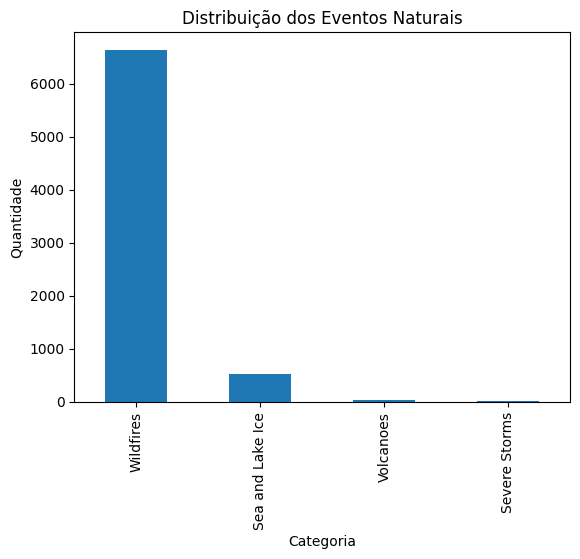

In [7]:
df["categoria"].value_counts().plot(kind="bar")
plt.title("Distribuição dos Eventos Naturais")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")
plt.show()

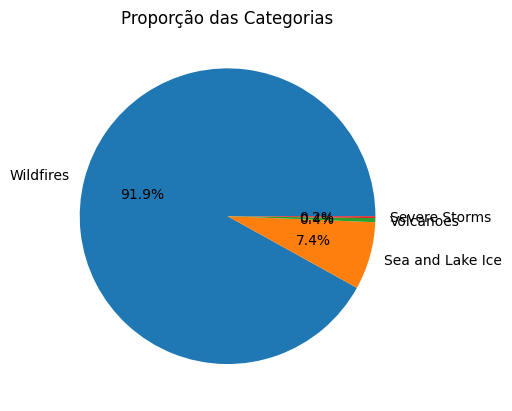

In [8]:
df["categoria"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Proporção das Categorias")
plt.show()

# 3. Pré-processamento e Engenharia de Atributos

In [9]:
df["data"] = pd.to_datetime(df["data"])

df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["dia"] = df["data"].dt.day
df["hora"] = df["data"].dt.hour

df["magnitude"] = df["magnitude"].fillna(0)

df.head()

,categoria,latitude,longitude,data,magnitude,ano,mes,dia,hora
0,Severe Storms,13.1,135.9,2026-05-28 06:00:00+00:00,35.0,2026,5,28,6
1,Severe Storms,13.9,135.4,2026-05-28 12:00:00+00:00,35.0,2026,5,28,12
2,Severe Storms,14.6,134.5,2026-05-28 18:00:00+00:00,40.0,2026,5,28,18
3,Severe Storms,15.4,133.7,2026-05-29 00:00:00+00:00,40.0,2026,5,29,0
4,Severe Storms,15.9,132.8,2026-05-29 06:00:00+00:00,40.0,2026,5,29,6


In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["categoria_encoded"] = encoder.fit_transform(df["categoria"])

df.head()

,categoria,latitude,longitude,data,magnitude,ano,mes,dia,hora,categoria_encoded
0,Severe Storms,13.1,135.9,2026-05-28 06:00:00+00:00,35.0,2026,5,28,6,1
1,Severe Storms,13.9,135.4,2026-05-28 12:00:00+00:00,35.0,2026,5,28,12,1
2,Severe Storms,14.6,134.5,2026-05-28 18:00:00+00:00,40.0,2026,5,28,18,1
3,Severe Storms,15.4,133.7,2026-05-29 00:00:00+00:00,40.0,2026,5,29,0,1
4,Severe Storms,15.9,132.8,2026-05-29 06:00:00+00:00,40.0,2026,5,29,6,1


In [11]:
print(df.isnull().sum())

categoria            0
latitude             0
longitude            0
data                 0
magnitude            0
ano                  0
mes                  0
dia                  0
hora                 0
categoria_encoded    0
dtype: int64


# 4. Desenvolvimento dos Modelos Preditivos

In [12]:
X = df[[
    "latitude",
    "longitude",
    "magnitude",
    "ano",
    "mes",
    "dia",
    "hora"
]]

y = df["categoria_encoded"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(5772, 7) (1444, 7)


## 4.1 Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print(f"Accuracy Random Forest: {acc_rf*100:.2f}%")
print(classification_report(y_test, pred_rf))

Accuracy Random Forest: 99.93%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       107
           1       1.00      1.00      1.00         3
           2       1.00      0.83      0.91         6
           3       1.00      1.00      1.00      1328

    accuracy                           1.00      1444
   macro avg       1.00      0.96      0.98      1444
weighted avg       1.00      1.00      1.00      1444



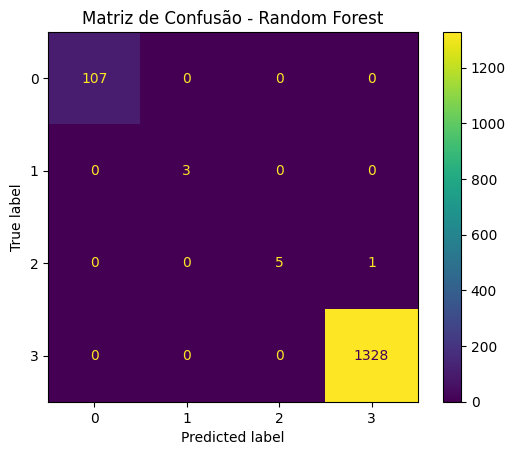

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, pred_rf)

ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Matriz de Confusão - Random Forest")
plt.show()

## 4.2 XGBoost

In [16]:
!pip install xgboost -q

In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, pred_xgb)

print(f"Accuracy XGBoost: {acc_xgb*100:.2f}%")
print(classification_report(y_test, pred_xgb))

Accuracy XGBoost: 99.93%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       107
           1       1.00      1.00      1.00         3
           2       1.00      0.83      0.91         6
           3       1.00      1.00      1.00      1328

    accuracy                           1.00      1444
   macro avg       1.00      0.96      0.98      1444
weighted avg       1.00      1.00      1.00      1444



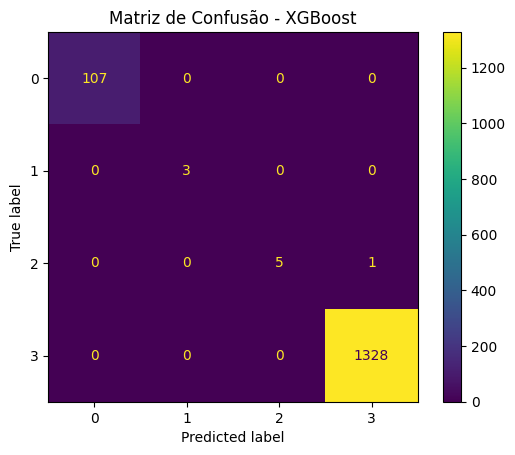

In [18]:
cm_xgb = confusion_matrix(y_test, pred_xgb)

ConfusionMatrixDisplay(cm_xgb).plot()
plt.title("Matriz de Confusão - XGBoost")
plt.show()

## 4.3 Comparação dos Modelos

In [19]:
resultado = pd.DataFrame({
    "Modelo":["Random Forest","XGBoost"],
    "Accuracy":[acc_rf, acc_xgb]
})

resultado

,Modelo,Accuracy
0,Random Forest,0.999307
1,XGBoost,0.999307


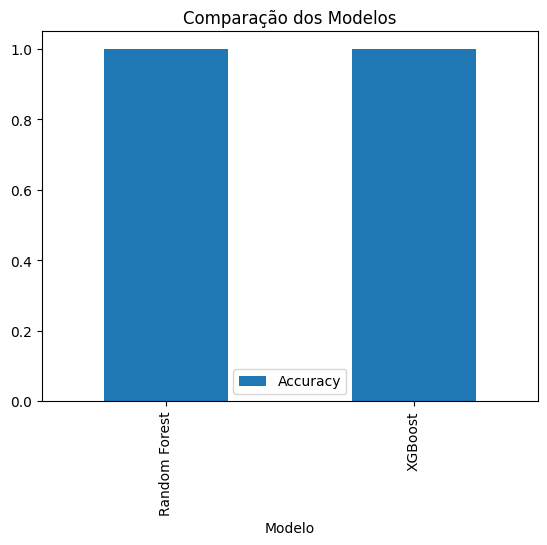

In [20]:
resultado.plot(
    x="Modelo",
    y="Accuracy",
    kind="bar"
)

plt.title("Comparação dos Modelos")
plt.show()

# 4.4 Escolha do Modelo Final

In [34]:
if acc_rf >= acc_xgb:
    melhor_modelo = rf
    nome_modelo = "Random Forest"
else:
    melhor_modelo = xgb
    nome_modelo = "XGBoost"

print("Modelo selecionado:", nome_modelo)

Modelo selecionado: Random Forest


### Justificativa da Escolha

Os modelos Random Forest e XGBoost apresentaram desempenho semelhante, alcançando aproximadamente 99,93% de acurácia.

O modelo selecionado para as próximas etapas foi o Random Forest devido à sua simplicidade de implementação, menor custo computacional e facilidade de interpretação quando comparado ao XGBoost.

# 5. Pipeline de Machine Learning

In [21]:
print('''
1. Coleta NASA EONET
2. Construção do Dataset
3. Pré-processamento
4. Engenharia de Atributos
5. Treinamento
6. Avaliação
7. Comparação
8. SHAP
9. Deploy
''')


1. Coleta NASA EONET
2. Construção do Dataset
3. Pré-processamento
4. Engenharia de Atributos
5. Treinamento
6. Avaliação
7. Comparação
8. SHAP
9. Deploy



# 6. Interpretabilidade com SHAP

In [22]:
!pip install shap -q
import shap

In [23]:
melhor_modelo = rf if acc_rf >= acc_xgb else xgb
explainer = shap.TreeExplainer(melhor_modelo)
shap_values = explainer.shap_values(X_test)

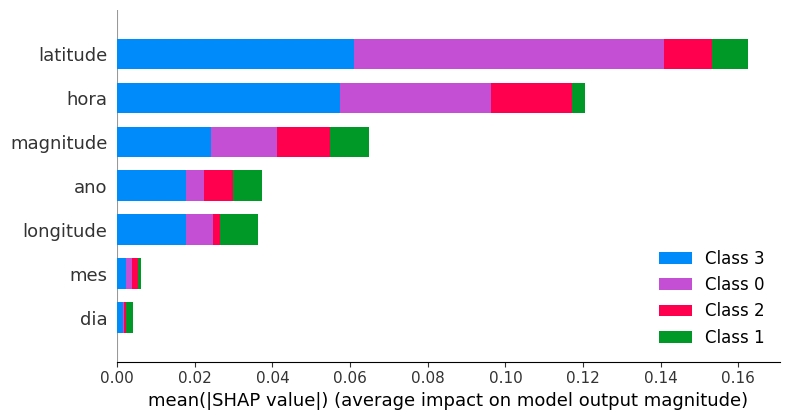

In [24]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

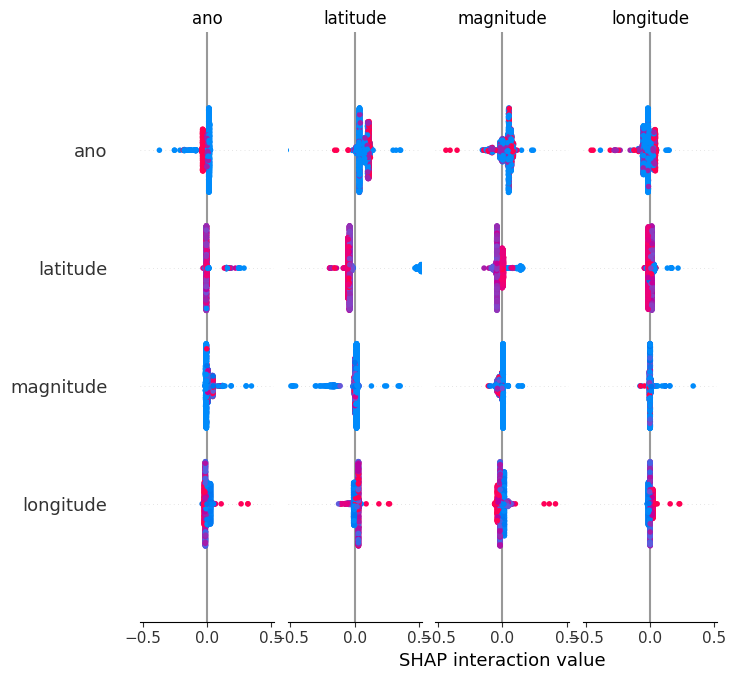

In [25]:
shap.summary_plot(
    shap_values,
    X_test
)

# 7. Salvamento do Modelo

In [26]:
import joblib

joblib.dump(
    melhor_modelo,
    'spaceguard_model.pkl'
)

print('Modelo salvo com sucesso!')

Modelo salvo com sucesso!


# 8. Exemplo de Predição

In [27]:
amostra = X_test.iloc[[0]]
amostra

,latitude,longitude,magnitude,ano,mes,dia,hora
540,33.178082,-83.741364,1607.0,2026,3,10,16


In [28]:
predicao = melhor_modelo.predict(amostra)

print(
    'Classe prevista:',
    encoder.inverse_transform(predicao)
)

Classe prevista: ['Wildfires']


In [29]:
valor_real = y_test.iloc[0]

print(
    'Valor real:',
    encoder.inverse_transform([valor_real])[0]
)

Valor real: Wildfires


# 9. Deploy da Solução

In [47]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

modelo = joblib.load("spaceguard_model.pkl")

classes = {
    0: "Sea and Lake Ice",
    1: "Severe Storms",
    2: "Volcanoes",
    3: "Wildfires"
}

st.title("🚀 SpaceGuard AI")
st.subheader("Classificação de Eventos Naturais com Dados da NASA")

latitude = st.number_input("Latitude")
longitude = st.number_input("Longitude")
magnitude = st.number_input("Magnitude", value=0.0)

ano = st.number_input("Ano", value=2025)
mes = st.number_input("Mês", value=1)
dia = st.number_input("Dia", value=1)
hora = st.number_input("Hora", value=12)

if st.button("Realizar Previsão"):

    entrada = pd.DataFrame({
        "latitude": [latitude],
        "longitude": [longitude],
        "magnitude": [magnitude],
        "ano": [ano],
        "mes": [mes],
        "dia": [dia],
        "hora": [hora]
    })

    previsao = modelo.predict(entrada)

    categoria = classes[int(previsao[0])]

    st.success(f"Categoria prevista: {categoria}")

Writing app.py


# 10. Conclusão
O projeto SpaceGuard utilizou dados reais da API NASA EONET para monitoramento de eventos naturais.

Foram coletados 7.216 registros de eventos naturais, utilizados para treinamento de modelos de Machine Learning.

Os modelos Random Forest e XGBoost alcançaram aproximadamente 99,93% de acurácia na classificação dos eventos.

A utilização do SHAP permitiu interpretar as decisões do modelo, identificando Latitude, Hora e Magnitude como os atributos mais relevantes para as previsões.

O projeto demonstra o potencial da Inteligência Artificial aplicada à Economia Espacial para automatizar o monitoramento de fenômenos naturais em escala global.

Além disso, a solução proposta pode servir como base para sistemas de alerta precoce utilizados por órgãos ambientais, equipes de resposta a desastres e instituições de pesquisa.